## Steam trajectory - Data visualization

#### After ingesting all the data (the Kaggle set to get the cohort, Steamcharts scraping to get the data) and loading it into the notebook, let's visualize the data. We want to investigate the anomolous "earliest_month_tracked" field as well since it had 2 dates coming up frequently.

In [23]:
%load_ext autoreload
%autoreload 2

import os
os.chdir("/Users/pmacias/Dropbox/steamproject")
print(os.getcwd())

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
/Users/pmacias/Dropbox/steamproject


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from steam_trajectory.db.connection import get_connection

conn = get_connection("steam_project.db")

In [25]:
history_df = pd.read_sql("""
    SELECT g.appid, g.name, g.release_date,
           MIN(m.month) AS earliest_tracked_month
    FROM games g
    JOIN monthly_metrics m ON g.appid = m.appid
    GROUP BY g.appid
""", conn)

history_df["release_date_parsed"] = pd.to_datetime(history_df["release_date"], errors="coerce")
history_df["earliest_tracked_parsed"] = pd.to_datetime(history_df["earliest_tracked_month"], errors="coerce")
history_df["gap_months"] = (
    (history_df["earliest_tracked_parsed"] - history_df["release_date_parsed"])
    / pd.Timedelta(days=30.44)
).round(1)

print("Most common earliest_tracked_month values:")
print(history_df["earliest_tracked_month"].value_counts().head(10))

Most common earliest_tracked_month values:
earliest_tracked_month
2020-06-01    21
2022-10-01    14
2022-06-01    13
2021-09-01    12
2021-10-01    12
2021-11-01    12
2020-08-01    11
2020-10-01    11
2020-11-01    11
2019-10-01    10
Name: count, dtype: int64


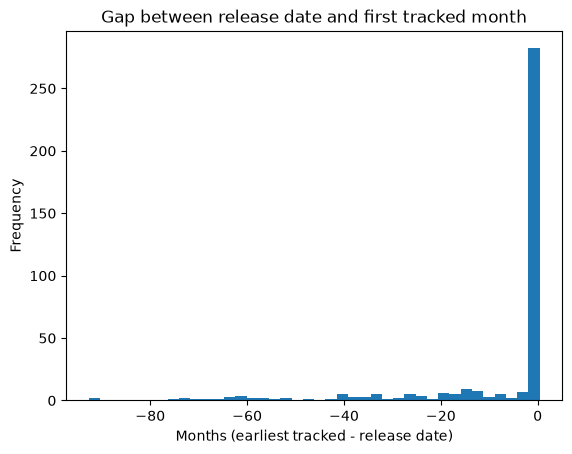

In [26]:
history_df["gap_months"].plot(kind="hist", bins=40, title="Gap between release date and first tracked month")
plt.xlabel("Months (earliest tracked - release date)")
plt.show()

In [27]:
large_gap = history_df[history_df["gap_months"] > 24].sort_values("gap_months", ascending=False)
print(f"{len(large_gap)} games with >24 month gap:")
large_gap[["name", "release_date", "earliest_tracked_month", "gap_months"]]

0 games with >24 month gap:


,name,release_date,earliest_tracked_month,gap_months


## Building the monthly time series

Two ways to anchor "time since launch" for each game:
- **months_since_first_tracked** — anchored on the first month SteamCharts has any data at all. Vulnerable to long pre-release Early Access history (see GearCity/Solasta earlier) landing a game's real full-launch spike well into the middle of its tracked timeline.
- **months_since_release** — anchored on the actual listed `release_date` from the Kaggle metadata. More directly comparable across games, but relies on `release_date` being meaningful (it can be a full-1.0-launch date well after a game's real engagement history began).

Both are computed below so we can directly compare — do the late-lifetime engagement spikes we kept seeing cluster more sensibly under one anchor than the other?

In [28]:
monthly_df = pd.read_sql("""
    SELECT appid, month, avg_players
    FROM monthly_metrics
    WHERE avg_players IS NOT NULL
    ORDER BY appid, month
""", conn)

monthly_df["month"] = pd.to_datetime(monthly_df["month"])
monthly_df["month_index"] = monthly_df["month"].dt.year * 12 + monthly_df["month"].dt.month

# Anchor 1: first tracked month (original approach)
monthly_df["months_since_first_tracked"] = (
    monthly_df.groupby("appid")["month_index"].transform(lambda x: x - x.min())
)

# Anchor 2: actual release date from game metadata
release_info = pd.read_sql("SELECT appid, release_date FROM games", conn)
release_info["release_date"] = pd.to_datetime(release_info["release_date"])
release_info["release_month_index"] = (
    release_info["release_date"].dt.year * 12 + release_info["release_date"].dt.month
)
monthly_df = monthly_df.merge(release_info[["appid", "release_month_index"]], on="appid")
monthly_df["months_since_release"] = monthly_df["month_index"] - monthly_df["release_month_index"]

print(monthly_df[["months_since_first_tracked", "months_since_release"]].describe())

       months_since_first_tracked  months_since_release
count                27549.000000          27549.000000
mean                    39.470761             28.077825
std                     26.999440             26.909875
min                      0.000000            -92.000000
25%                     18.000000             11.000000
50%                     36.000000             29.000000
75%                     56.000000             47.000000
max                    167.000000             89.000000


In [29]:
completeness = monthly_df.groupby("appid")["months_since_first_tracked"].agg(["min", "max", "count"]).reset_index()
completeness["expected_months"] = completeness["max"] - completeness["min"] + 1
completeness["completeness_pct"] = completeness["count"] / completeness["expected_months"] * 100

print(completeness["completeness_pct"].describe())

count    380.000000
mean      99.454508
std        3.201276
min       64.957265
25%      100.000000
50%      100.000000
75%      100.000000
max      100.000000
Name: completeness_pct, dtype: float64


### Comparing the two anchors directly
Same 382-ish games, same underlying data — only the x-axis anchor differs between these two panels. If `months_since_release` clusters late-lifetime spikes more sensibly (e.g. around known DLC/re-release windows rather than scattered arbitrarily), that's evidence it's the more honest anchor to standardize on going forward.

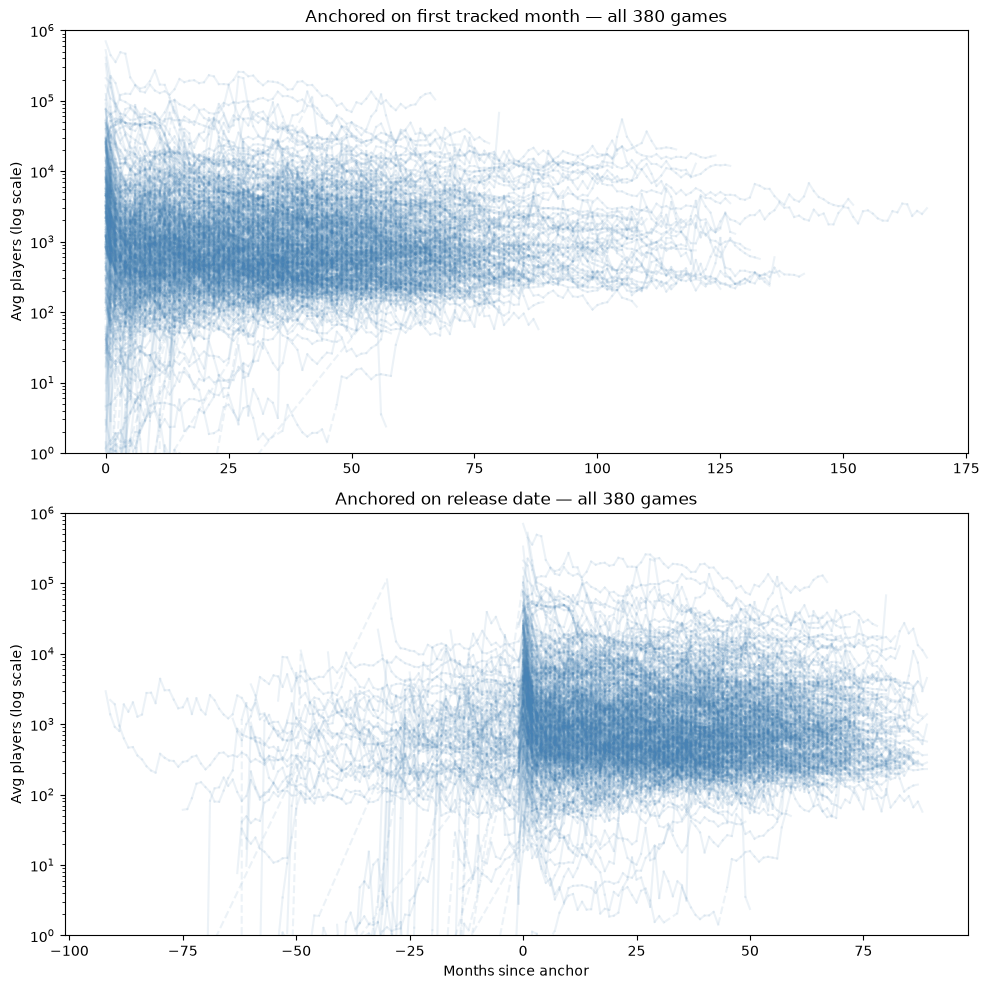

In [46]:
def plot_with_gaps(ax, x, y, color, alpha):
    """Plots a single game's line, using a dashed segment anywhere
    the underlying months aren't consecutive (a real data gap) and
    a solid segment where they are — so a gap-bridging line reads
    visually as 'we don't know what happened here', not as a
    genuine observed trend."""
    x, y = np.asarray(x), np.asarray(y)
    order = np.argsort(x)
    x, y = x[order], y[order]
    for i in range(len(x) - 1):
        is_gap = (x[i + 1] - x[i]) > 1
        ax.plot(x[i:i+2], y[i:i+2], linestyle="--" if is_gap else "-",
                color=color, alpha=alpha)

n_games = monthly_df["appid"].nunique()
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharey=True)

for appid, group in monthly_df.groupby("appid"):
    plot_with_gaps(ax1, group["months_since_first_tracked"], group["avg_players"], "steelblue", 0.1)
    plot_with_gaps(ax2, group["months_since_release"], group["avg_players"], "steelblue", 0.1)

ax1.set_yscale("log")
ax1.set_title(f"Anchored on first tracked month — all {n_games} games")
ax1.set_ylabel("Avg players (log scale)")
ax1.set_ylim(1e0,1e6)

ax2.set_yscale("log")
ax2.set_title(f"Anchored on release date — all {n_games} games")
ax2.set_xlabel("Months since anchor")
ax2.set_ylabel("Avg players (log scale)")
ax2.set_ylim(1e0,1e6)

plt.tight_layout()
plt.show()

### Adopting `months_since_release` going forward
Based on the comparison above, `months_since_release` is the anchor used for everything downstream (completeness checks already used `months_since_first_tracked` above for the original diagnostic — kept as-is for that historical investigation). The normalized-to-peak panel below, the classification, and the early/late scatter all use `months_since_release`.

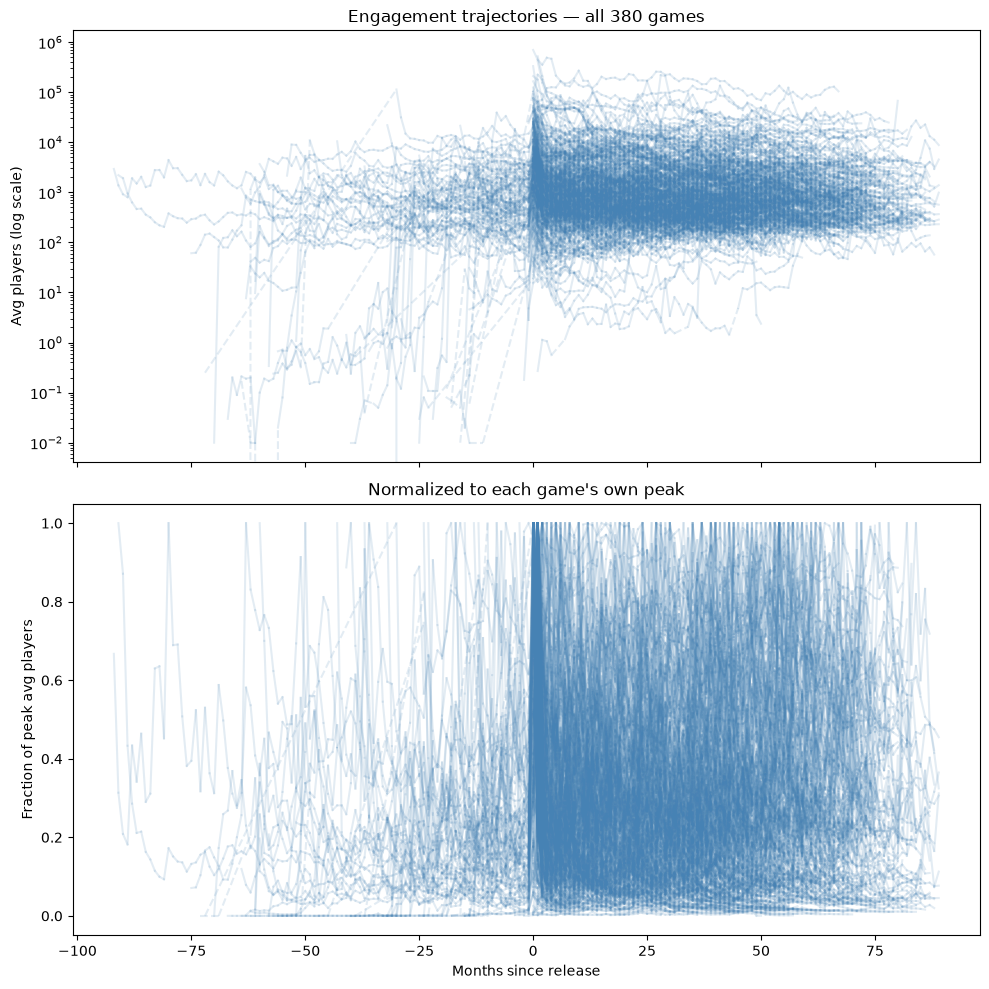

In [31]:
peak_per_game = monthly_df.groupby("appid")["avg_players"].transform("max")
monthly_df["normalized_players"] = monthly_df["avg_players"] / peak_per_game

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

for appid, group in monthly_df.groupby("appid"):
    plot_with_gaps(ax1, group["months_since_release"], group["avg_players"], "steelblue", 0.15)
    plot_with_gaps(ax2, group["months_since_release"], group["normalized_players"], "steelblue", 0.15)

ax1.set_yscale("log")
ax1.set_ylabel("Avg players (log scale)")
ax1.set_title(f"Engagement trajectories — all {monthly_df['appid'].nunique()} games")

ax2.set_ylabel("Fraction of peak avg players")
ax2.set_xlabel("Months since release")
ax2.set_title("Normalized to each game's own peak")

plt.tight_layout()
plt.show()

In [32]:
db_appids = set(pd.read_sql("SELECT DISTINCT appid FROM monthly_metrics", conn)["appid"])
cohort_appids = set(pd.read_sql("SELECT appid FROM games", conn)["appid"])

print("Games table has:", len(cohort_appids), "games")
print("In monthly_metrics but not in games table:", db_appids - cohort_appids)
print("In games table but missing from monthly_metrics:", cohort_appids - db_appids)

Games table has: 380 games
In monthly_metrics but not in games table: set()
In games table but missing from monthly_metrics: set()


In [33]:
# For each game, find every month that's "near-peak" (within 90%
# of its own max) and see how spread out those near-peak months are
near_peak = monthly_df[monthly_df["normalized_players"] >= 0.9]
spread = near_peak.groupby("appid")["months_since_release"].agg(["count", "min", "max"])
spread["spread_months"] = spread["max"] - spread["min"]

# Bring in each game's actual peak avg_players, to test the
# low-count-noise theory directly
spread = spread.join(monthly_df.groupby("appid")["avg_players"].max().rename("peak_avg_players"))

# Sort by spread — the widest-spread "comb" offenders first
spread.sort_values("spread_months", ascending=False).head(15)

,count,min,max,spread_months,peak_avg_players
appid,,,,,
268650,4,-63,49,112,858.85
813780,12,5,78,73,19509.70
952060,2,0,71,71,5771.40
1182020,3,0,62,62,252.49
1012880,2,0,54,54,393.57
860510,2,0,53,53,2760.76
1478220,4,1,50,49,390.51
898920,6,-19,27,46,684.28
1145360,4,1,44,43,19587.12


### Lifetime peak distribution
On a log axis, this looks roughly symmetric — meaning `Peak CCU` is approximately **log-normal**, not normal. This is a very common pattern for multiplicative-growth-driven quantities (city sizes, wealth, stellar luminosities) — worth building Week 2 features in log-space rather than raw CCU, and it's a genuinely useful, citable property of the cohort.

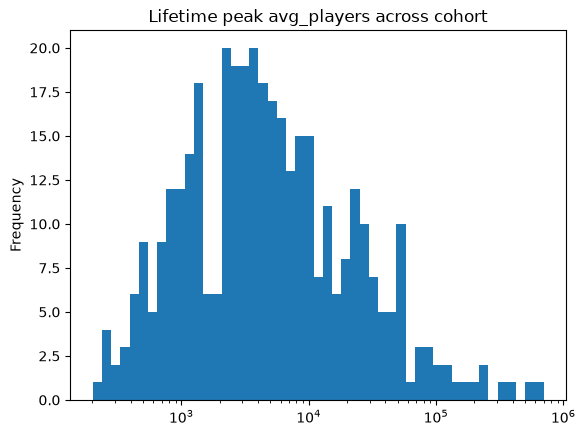

count       380.000000
mean      18774.521000
std       58232.259188
min         200.970000
25%        1497.955000
50%        4174.295000
75%       12453.157500
max      699094.080000
Name: avg_players, dtype: float64

In [34]:
peak_lifetime = monthly_df.groupby("appid")["avg_players"].max()

# Equal-width bins in LOG space (not just a log-scaled axis on top of
# linear bins) — np.logspace generates edges that grow multiplicatively,
# matching the heavy-tailed, many-orders-of-magnitude shape of this data
log_bins = np.logspace(
    np.log10(peak_lifetime[peak_lifetime > 0].min()),
    np.log10(peak_lifetime.max()),
    50
)

peak_lifetime.plot(kind="hist", bins=log_bins, title="Lifetime peak avg_players across cohort")
plt.xscale("log")
plt.show()

peak_lifetime.describe()

<Axes: xlabel='genre'>

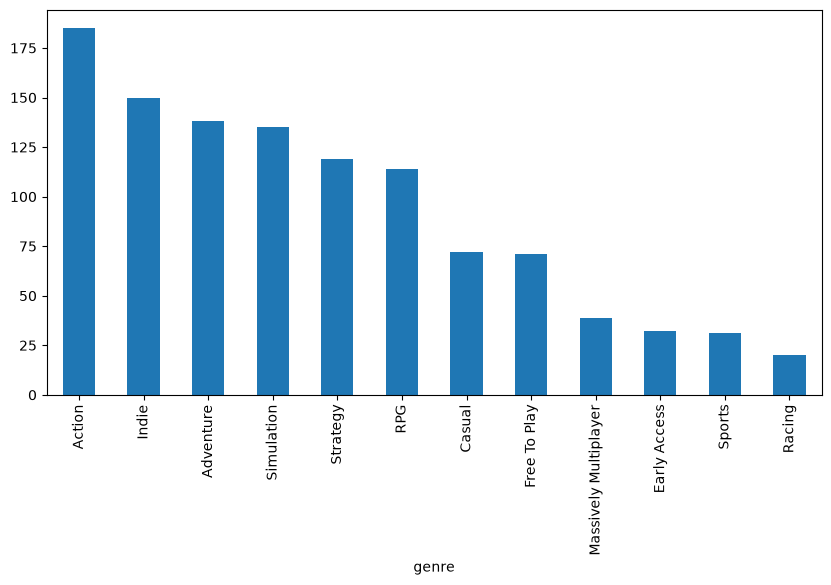

In [35]:
genre_counts = pd.read_sql("""
    SELECT gen.name AS genre, COUNT(*) as n
    FROM game_genres gg
    JOIN genres gen ON gg.genre_id = gen.genre_id
    GROUP BY gen.name
    ORDER BY n DESC
""", conn)
genre_counts.plot(kind="bar", x="genre", y="n", figsize=(10,5), legend=False)

## Early signal vs. later outcome
Using `months_since_release` now, consistent with the rest of this notebook. A floor filter (`> 0`) is applied before the log transform — a handful of games have literally zero average players in a window, and `log10(0)` breaks the residual fit (see the LinAlgError we hit earlier).

Comparing 380 games after dropping zero/negative values


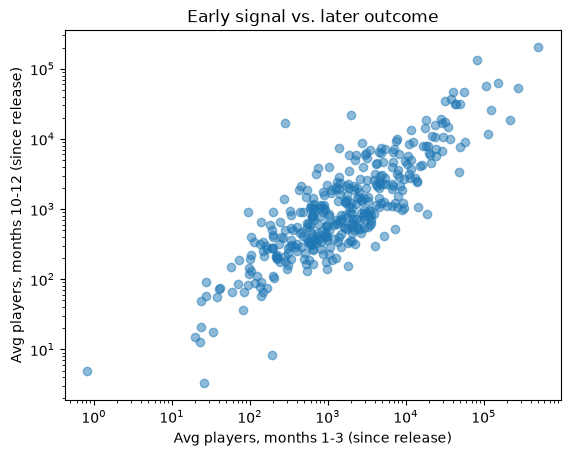

In [36]:
early = (monthly_df[monthly_df["months_since_release"] <= 3]
         .groupby("appid")["avg_players"].mean())
late = (monthly_df[(monthly_df["months_since_release"] >= 10) & (monthly_df["months_since_release"] <= 12)]
        .groupby("appid")["avg_players"].mean())

comparison = pd.DataFrame({"early": early, "late": late}).dropna()
comparison = comparison[(comparison["early"] > 0) & (comparison["late"] > 0)].copy()
print(f"Comparing {len(comparison)} games after dropping zero/negative values")

fig, ax = plt.subplots()
ax.scatter(comparison["early"], comparison["late"], alpha=0.5)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Avg players, months 1-3 (since release)")
ax.set_ylabel("Avg players, months 10-12 (since release)")
ax.set_title("Early signal vs. later outcome")
plt.show()

### Overperformers / underperformers
Residual from a fitted log-log trend line — how far each game's actual later outcome deviates from what its early signal alone would predict.

In [37]:
log_early = np.log10(comparison["early"])
log_late = np.log10(comparison["late"])

slope, intercept = np.polyfit(log_early, log_late, 1)
predicted_log_late = slope * log_early + intercept
comparison["residual"] = log_late - predicted_log_late

names = pd.read_sql("SELECT appid, name, release_date FROM games", conn)

overperformers = comparison.sort_values("residual", ascending=False).head(10)
underperformers = comparison.sort_values("residual", ascending=True).head(10)

print("Overperformers (early signal underestimated them):")
print(overperformers.join(names.set_index("appid"), on="appid")[["name", "early", "late", "residual"]])
print("\nUnderperformers (early signal overestimated them):")
print(underperformers.join(names.set_index("appid"), on="appid")[["name", "early", "late", "residual"]])

Overperformers (early signal underestimated them):
                                           name         early           late  \
appid                                                                          
1677740                            Stumble Guys    283.065000   16628.423333   
1238810                          Battlefield™ V   2011.888750   22057.456667   
548430                       Deep Rock Galactic   1409.668444    7502.626667   
400750   Call to Arms - Gates of Hell: Ostfront     95.567273     923.833333   
1172470                           Apex Legends™  83044.097500  134807.760000   
1238840                          Battlefield™ 1    744.347500    3848.750000   
1222670                             The Sims™ 4   2714.362500    8619.340000   
1238860                          Battlefield 4™    713.102500    3115.293333   
1665460                              eFootball™   1031.386667    4016.143333   
815370                               Green Hell    459.591875    2115

### Interactive version (hover for game name / release date)
Requires `plotly` — not yet in `pyproject.toml`, add it (`pip install plotly` + add to dependencies) before running this cell.

In [39]:
import plotly.express as px

comparison_with_names = comparison.reset_index().merge(names, on="appid")

fig = px.scatter(
    comparison_with_names, x="early", y="late",
    hover_data=["name", "release_date", "residual"],
    log_x=True, log_y=True,
    title="Early signal vs. later outcome (hover for details)"
)
fig.show()

## Trajectory shape classification
Rule-based, no ML — a handful of summary statistics per trajectory, then simple threshold logic to bucket shapes. Order matters: multi-peak is checked *before* late_bloomer, since a game with a real early spike AND a later spike should be called spiky, not late_bloomer just because its single biggest peak happens to be the later one. `late_bloomer` now also requires no meaningful early activity at all (not just "peak happens after month 12"). `plateau` now requires the late segment to be a meaningful fraction of the game's own peak — otherwise a game that fully decayed to a tiny, steady trickle was wrongly called a plateau.

In [40]:
from scipy.signal import find_peaks

def classify_trajectory(group):
    group = group.sort_values("months_since_release")
    values = group["avg_players"].values
    months = group["months_since_release"].values
    peak_val = values.max()
    peak_month = months[values.argmax()]

    if peak_val < 20:
        return "fizzler"

    # Check multi-peak FIRST — a game with a real early spike and a
    # separate later spike should be "spiky", not "late_bloomer" just
    # because its single biggest peak happens to be the later one
    peaks, _ = find_peaks(values, height=peak_val * 0.5, distance=2)
    if len(peaks) >= 2:
        return "spiky_multipeak"

    # late_bloomer now requires genuinely negligible early activity,
    # not just "peak happened after month 12"
    early_window = values[months <= 12]
    if len(early_window) > 0 and early_window.max() < peak_val * 0.3 and peak_month > 12:
        return "late_bloomer"

    if len(values) >= 12:
        late_segment = values[-6:]
        # Plateau must be a meaningful FRACTION of the game's own peak,
        # not just internally stable — otherwise a fully-decayed game
        # sitting at a tiny, steady trickle gets mislabeled "plateau"
        if (late_segment.mean() / peak_val > 0.15
                and late_segment.std() / late_segment.mean() < 0.3):
            return "plateau"

    return "clean_decay"

shapes = monthly_df.groupby("appid").apply(classify_trajectory, include_groups=False)
shape_counts = shapes.value_counts()
print(shape_counts)

spiky_multipeak    212
clean_decay        118
plateau             43
late_bloomer         7
Name: count, dtype: int64


In [41]:
months_tracked = monthly_df.groupby("appid").size().rename("months_tracked")

shapes_df = shapes.reset_index()
shapes_df.columns = ["appid", "shape"]
shapes_df = shapes_df.join(months_tracked, on="appid")
shapes_df = shapes_df.join(pd.read_sql("SELECT appid, name FROM games", conn).set_index("appid"), on="appid")

# Top 2 per category by months tracked — most well-observed example
# of each shape, not just a random pick
examples = (
    shapes_df.sort_values("months_tracked", ascending=False)
    .groupby("shape")
    .head(2)
    .sort_values("shape")
)
print(examples)

       appid            shape  months_tracked  \
8     346010      clean_decay             137   
4     311310      clean_decay             126   
163  1071870     late_bloomer              75   
233  1222680     late_bloomer              73   
5     313120          plateau             138   
20    427520          plateau             125   
0      12210  spiky_multipeak             168   
1     244850  spiky_multipeak             153   

                                          name  
8                                      Besiege  
4                                 Naval Action  
163                                      Biped  
233                       Need for Speed™ Heat  
5                                Stranded Deep  
20                                    Factorio  
0    Grand Theft Auto IV: The Complete Edition  
1                              Space Engineers  


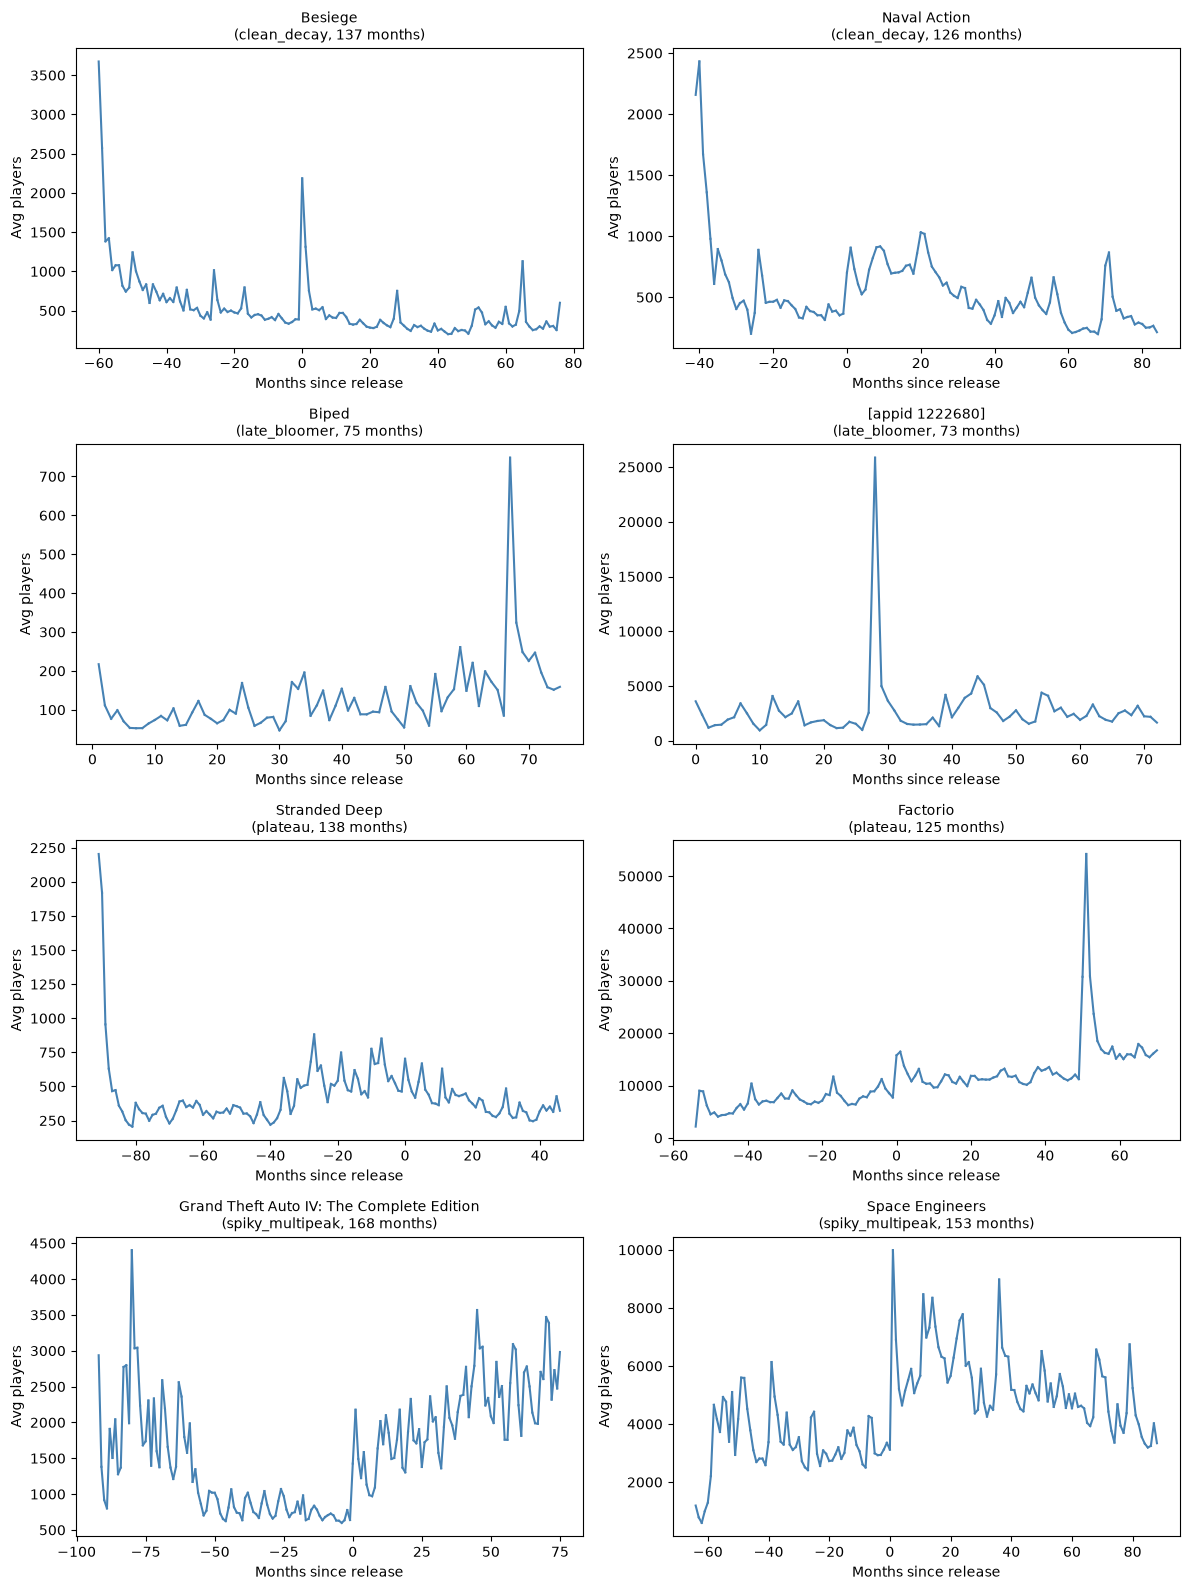

In [45]:
def safe_title(name, appid):
    """Falls back to appid if the name has characters matplotlib's
    default font can't render (e.g. CJK titles) — avoids UserWarning
    spam and blank-box glyphs in subplot titles."""
    try:
        name.encode("ascii")
        return name
    except UnicodeEncodeError:
        return f"[appid {appid}]"

n_examples = len(examples)
n_cols = 2
n_rows = -(-n_examples // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

for ax, (_, row) in zip(axes, examples.iterrows()):
    game_data = monthly_df[monthly_df["appid"] == row["appid"]].sort_values("months_since_release")
    plot_with_gaps(ax, game_data["months_since_release"], game_data["avg_players"], "steelblue", 1.0)
    #ax.set_yscale("log")
    title_name = safe_title(row["name"], row["appid"])
    ax.set_title(f"{title_name}\n({row['shape']}, {row['months_tracked']} months)", fontsize=10)
    ax.set_xlabel("Months since release")
    ax.set_ylabel("Avg players")

for ax in axes[n_examples:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

## Non-game genre check
Sanity check that no non-game software slipped through the cohort filter (see `00_cohort_selection.ipynb` for the filter logic). Generalized to work off whatever `suspect` actually finds, rather than hardcoded names from an earlier cohort version — this should come back empty now.

In [43]:
non_game_flags = ["Design & Illustration", "Animation & Modeling", "Education",
                   "Utilities", "Web Publishing", "Photo Editing",
                   "Software Training", "Video Production"]

suspect = pd.read_sql(f"""
    SELECT DISTINCT g.name, gen.name AS genre
    FROM games g
    JOIN game_genres gg ON g.appid = gg.appid
    JOIN genres gen ON gg.genre_id = gen.genre_id
    WHERE gen.name IN ({",".join(f"'{g}'" for g in non_game_flags)})
""", conn)
suspect

,name,genre


In [44]:
suspect_names = suspect["name"].unique().tolist()

if suspect_names:
    placeholders = ", ".join(f"'{n}'" for n in suspect_names)
    full_genres = pd.read_sql(f"""
        SELECT g.name, GROUP_CONCAT(gen.name, ', ') AS all_genres
        FROM games g
        JOIN game_genres gg ON g.appid = gg.appid
        JOIN genres gen ON gg.genre_id = gen.genre_id
        WHERE g.name IN ({placeholders})
        GROUP BY g.name
    """, conn)
else:
    print("No suspect non-game titles found in this cohort — nothing to cross-check.")
    full_genres = pd.DataFrame()

full_genres

No suspect non-game titles found in this cohort — nothing to cross-check.


""
